In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import ICIW_Plots

plt.style.use("ICIWstyle")
plt.rcParams["font.size"] = 7

In [28]:
n_dot_old = np.load(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\Experiments\HSA_004\data\FBA-E-19032025_250ml-min_2bar_250_TotalSystem_composition.npy")
timestamps = np.load(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\Experiments\HSA_004\data\FBA-E-19032025_250ml-min_2bar_250_TotalSystem_times.npy")

n_dot = np.load(r"C:\Users\AlexanderZirn\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_vor_Reaktor\RTD_vor_Reaktor_RT_250_Nml_min_MS_composition_with_GC.npy")
t_source = np.load(r"C:\Users\AlexanderZirn\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_vor_Reaktor\RTD_vor_Reaktor_RT_250_Nml_min_MS_times_with_GC.npy")

In [29]:
print(n_dot.shape)
print(n_dot_old.shape)

(44589, 3)
(149166, 3)


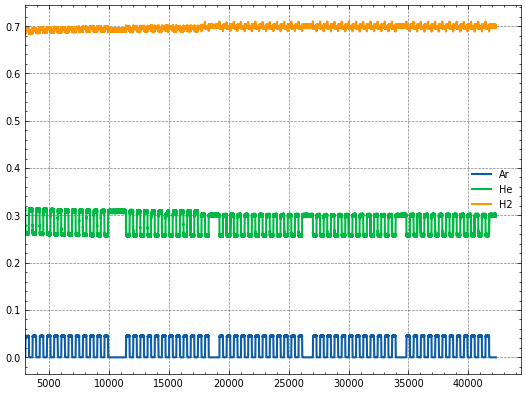

In [30]:
plt.plot(timestamps, n_dot_old[:,0], label="Ar", color="C0")
plt.plot(timestamps, n_dot_old[:,1], label="He", color="C1")
plt.plot(timestamps, n_dot_old[:,2], label="H2", color="C2")
plt.xlim(20.25 + 45 * 60 + 5 * 60,)
plt.legend()

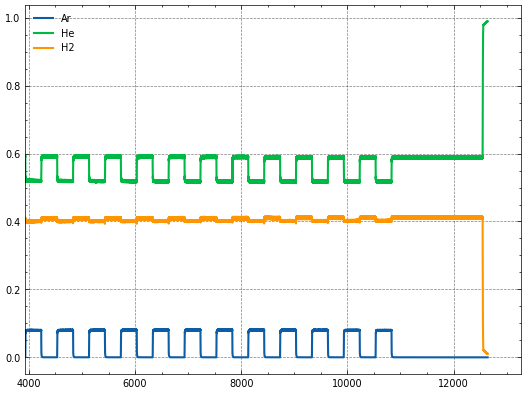

In [31]:
plt.plot(t_source, n_dot[:,0], label="Ar", color="C0")
plt.plot(t_source, n_dot[:,1], label="He", color="C1")
plt.plot(t_source, n_dot[:,2], label="H2", color="C2")
plt.xlim(65.5*60,)
plt.legend()

In [32]:
time_delta = t_source - t_source[0]

np.savez(
    "AZA-E-130625_250ml-min_2bar_250_upstream.npz",
    n_dot=n_dot.T,
    time_delta=time_delta,
)

t_range = (time_delta.min(), time_delta.max())

In [33]:
# create array with half-period times

t_offset = 65.5*60 # offset until experiment starts
t_halfperiod = 300 # 5min half-period duration

switching_times = np.full((24,), t_halfperiod) #+ np.array([0.05,
                                                        #   0.18,
                                                        #   0.27,
                                                        #   0.33,
                                                        #   0.26,
                                                        #   0.18,
                                                        #   0.28,
                                                        #   0.27,
                                                        #   0.27,
                                                        #   0.03])# 24 half-periods
print(switching_times)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300
 300 300 300 300 300 300]
[ 3930  4230  4530  4830  5130  5430  5730  6030  6330  6630  6930  7230
  7530  7830  8130  8430  8730  9030  9330  9630  9930 10230 10530 10830
 11130]
[(np.int64(3930), np.int64(4230)), (np.int64(4230), np.int64(4530)), (np.int64(4530), np.int64(4830)), (np.int64(4830), np.int64(5130)), (np.int64(5130), np.int64(5430)), (np.int64(5430), np.int64(5730)), (np.int64(5730), np.int64(6030)), (np.int64(6030), np.int64(6330)), (np.int64(6330), np.int64(6630)), (np.int64(6630), np.int64(6930)), (np.int64(6930), np.int64(7230)), (np.int64(7230), np.int64(7530)), (np.int64(7530), np.int64(7830)), (np.int64(7830), np.int64(8130)), (np.int64(8130), np.int64(8430)), (np.int64(8430), np.int64(8730)), (np.int64(8730), np.int64(9030)), (np.int64(9030), np.int64(9330)), (np.int64(9330), np.int64(9630)), (np.int64(9630), np.int64(9930)), (np.int64(9930), np.int64(10230)), (np.int64(10230), np.int64(1053

In [34]:
print(time_delta.shape)
print(n_dot.shape)

(44589,)
(44589, 3)


In [35]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot.T,
    kind="linear",
    fill_value="extrapolate",
)

In [36]:
t = np.linspace(*t_range, 481)
n_dot_interp = interp(t)

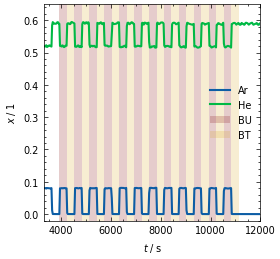

In [37]:
fig = plt.figure()
ax = ICIW_Plots.make_square_ax(
    fig=fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    xlabel="$t\;/\;\mathrm{s}$",
    ylabel="$x\;/\; 1$",
    xlim=(3300, 12000),
    ylim=(-0.02, 0.65),
)
ax.grid(False)
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")


for interval in intervals[::2]:
    plt.fill_betweenx(
        [-0.1, 0.7],
        interval[0],
        interval[1],
        alpha=0.2,
        color="maroon",
        edgecolor=None,
        zorder=-1,
        label="BU",
    )
for interval in intervals[1::2]:
    plt.fill_betweenx(
        [-0.1, 0.7],
        interval[0],
        interval[1],
        alpha=0.2,
        color="goldenrod",
        edgecolor=None,
        zorder=-1,
        label="BT",
    )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.savefig("exp_data_with_halfperiods.png", dpi=600)

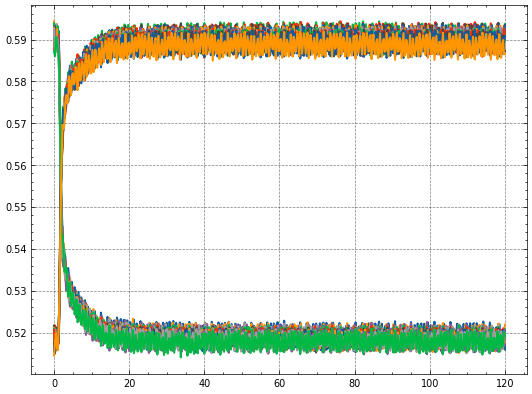

In [38]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 120, 480 + 1)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[1])

In [39]:
%pip install torch
%pip install lightning

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\AlexanderZirn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\AlexanderZirn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
import sys

sys.path.append(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting import RTDDataModule

data_total_system = RTDDataModule(
    batch_size=32, # 2 temperatures, 2 half-periods, 4 different capillary positions
    data_file=Path(
        r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\Experiments\AZA_001\B - upstream\AZA-E-130625_250ml-min_2bar_250_upstream.npz"),
    switching_times=switching_times,
    t_range_in=(0, 10), # kernel discretization
    n_in=41, # kernel
    t_range_out=(0, 120), # time range of output time series
    n_out=481,  # number of points in output time series in s (4 MS measurements per second)
    switch_delay=1.0,
)

In [41]:
data_total_system.setup("fit")
data_total_system.x[0]

tensor([[8.7911e-05, 8.7911e-05, 8.7911e-05, 8.7911e-05, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02,
         8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02, 8.0276e-02]],
       dtype=torch.float64)

In [42]:
print(data_total_system.x.shape) # 48 = 3 * 16, 3 components

torch.Size([48, 1, 41])


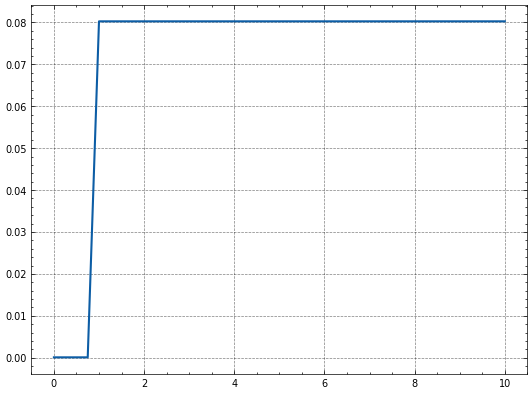

In [43]:
%matplotlib inline
plt.plot(data_total_system.t_in[0,:], data_total_system.x[0,0,:])
plt.show()
plt.close()

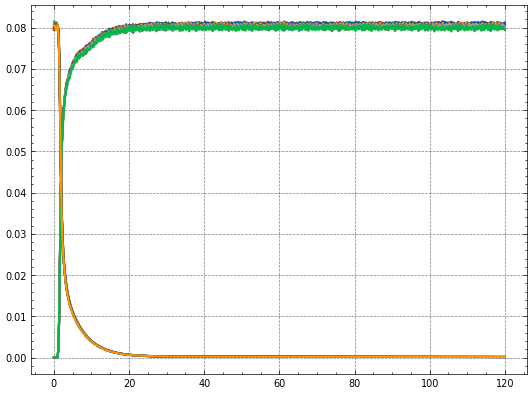

In [44]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,48):
    if i %2==0:
        plt.plot(data_total_system.t_out[i, :], data_total_system.y[i, 0, ...], label="Ar")
plt.show()
plt.close()

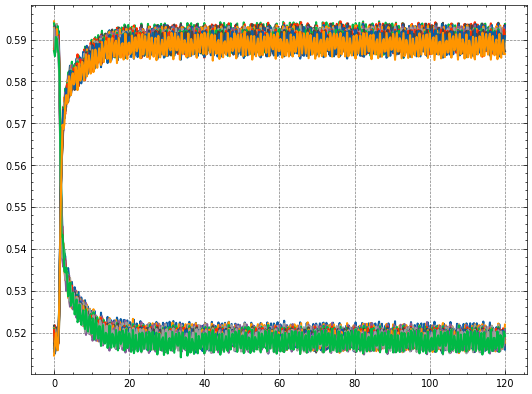

In [45]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,48):
    if not i %2==0:
        plt.plot(data_total_system.t_out[i, :], data_total_system.y[i, 0, ...], label="He")
plt.show()
plt.close()

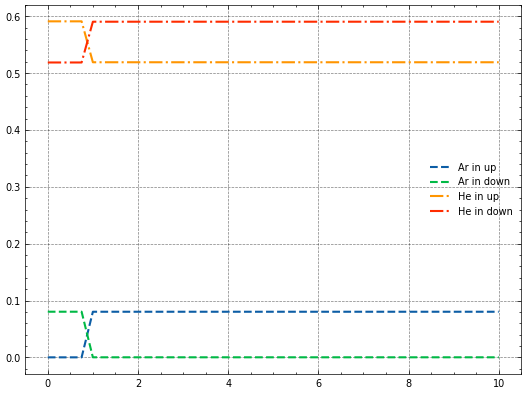

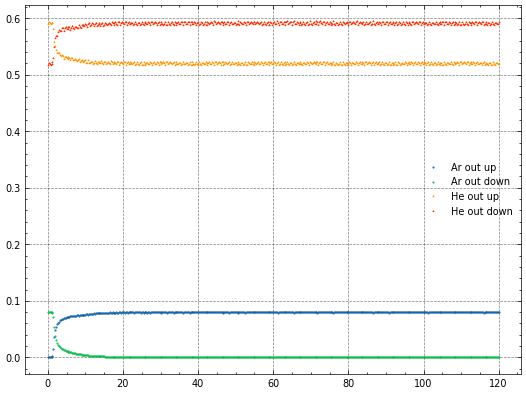

In [46]:
%matplotlib notebook
%matplotlib inline

fig = plt.figure()
index = 0
plt.plot(
    data_total_system.t_in[index],
    data_total_system.x[index].squeeze(),
    ls="--", label ='Ar in up'
)
plt.plot(
    data_total_system.t_in[index + 2],
    data_total_system.x[index + 2].squeeze(),
    ls="--", label = 'Ar in down'
)
plt.plot(
    data_total_system.t_in[index+1],
    data_total_system.x[index+1].squeeze(),
    ls="-.", label ='He in up'
)
plt.plot(
    data_total_system.t_in[index + 3],
    data_total_system.x[index + 3].squeeze(),
    ls="-.", label ='He in down'
)
plt.legend()
plt.show()


plt.plot(
    data_total_system.t_out[index],
    data_total_system.y[index].squeeze(),
    "o",
    markersize=0.5, label ='Ar out up'
)
plt.plot(
    data_total_system.t_out[index + 2],
    data_total_system.y[index + 2].squeeze(),
    "o",
    markersize=0.5, label ='Ar out down'
)
plt.plot(
    data_total_system.t_out[index+1],
    data_total_system.y[index+1].squeeze(),
    "v",
    markersize=0.5, label ='He out up'
)
plt.plot(
    data_total_system.t_out[index + 3],
    data_total_system.y[index + 3].squeeze(),
    "v",
    markersize=0.5, label ='He out down'
)
plt.legend()
plt.show()